# Model Explanation

## K-nn

## Decision Tree

In [4]:
## Decision Tree
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [6]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [8]:
clf = DecisionTreeClassifier(random_state=1234) # Initalize Classifier
model = clf.fit(X, y) # Classifer Training

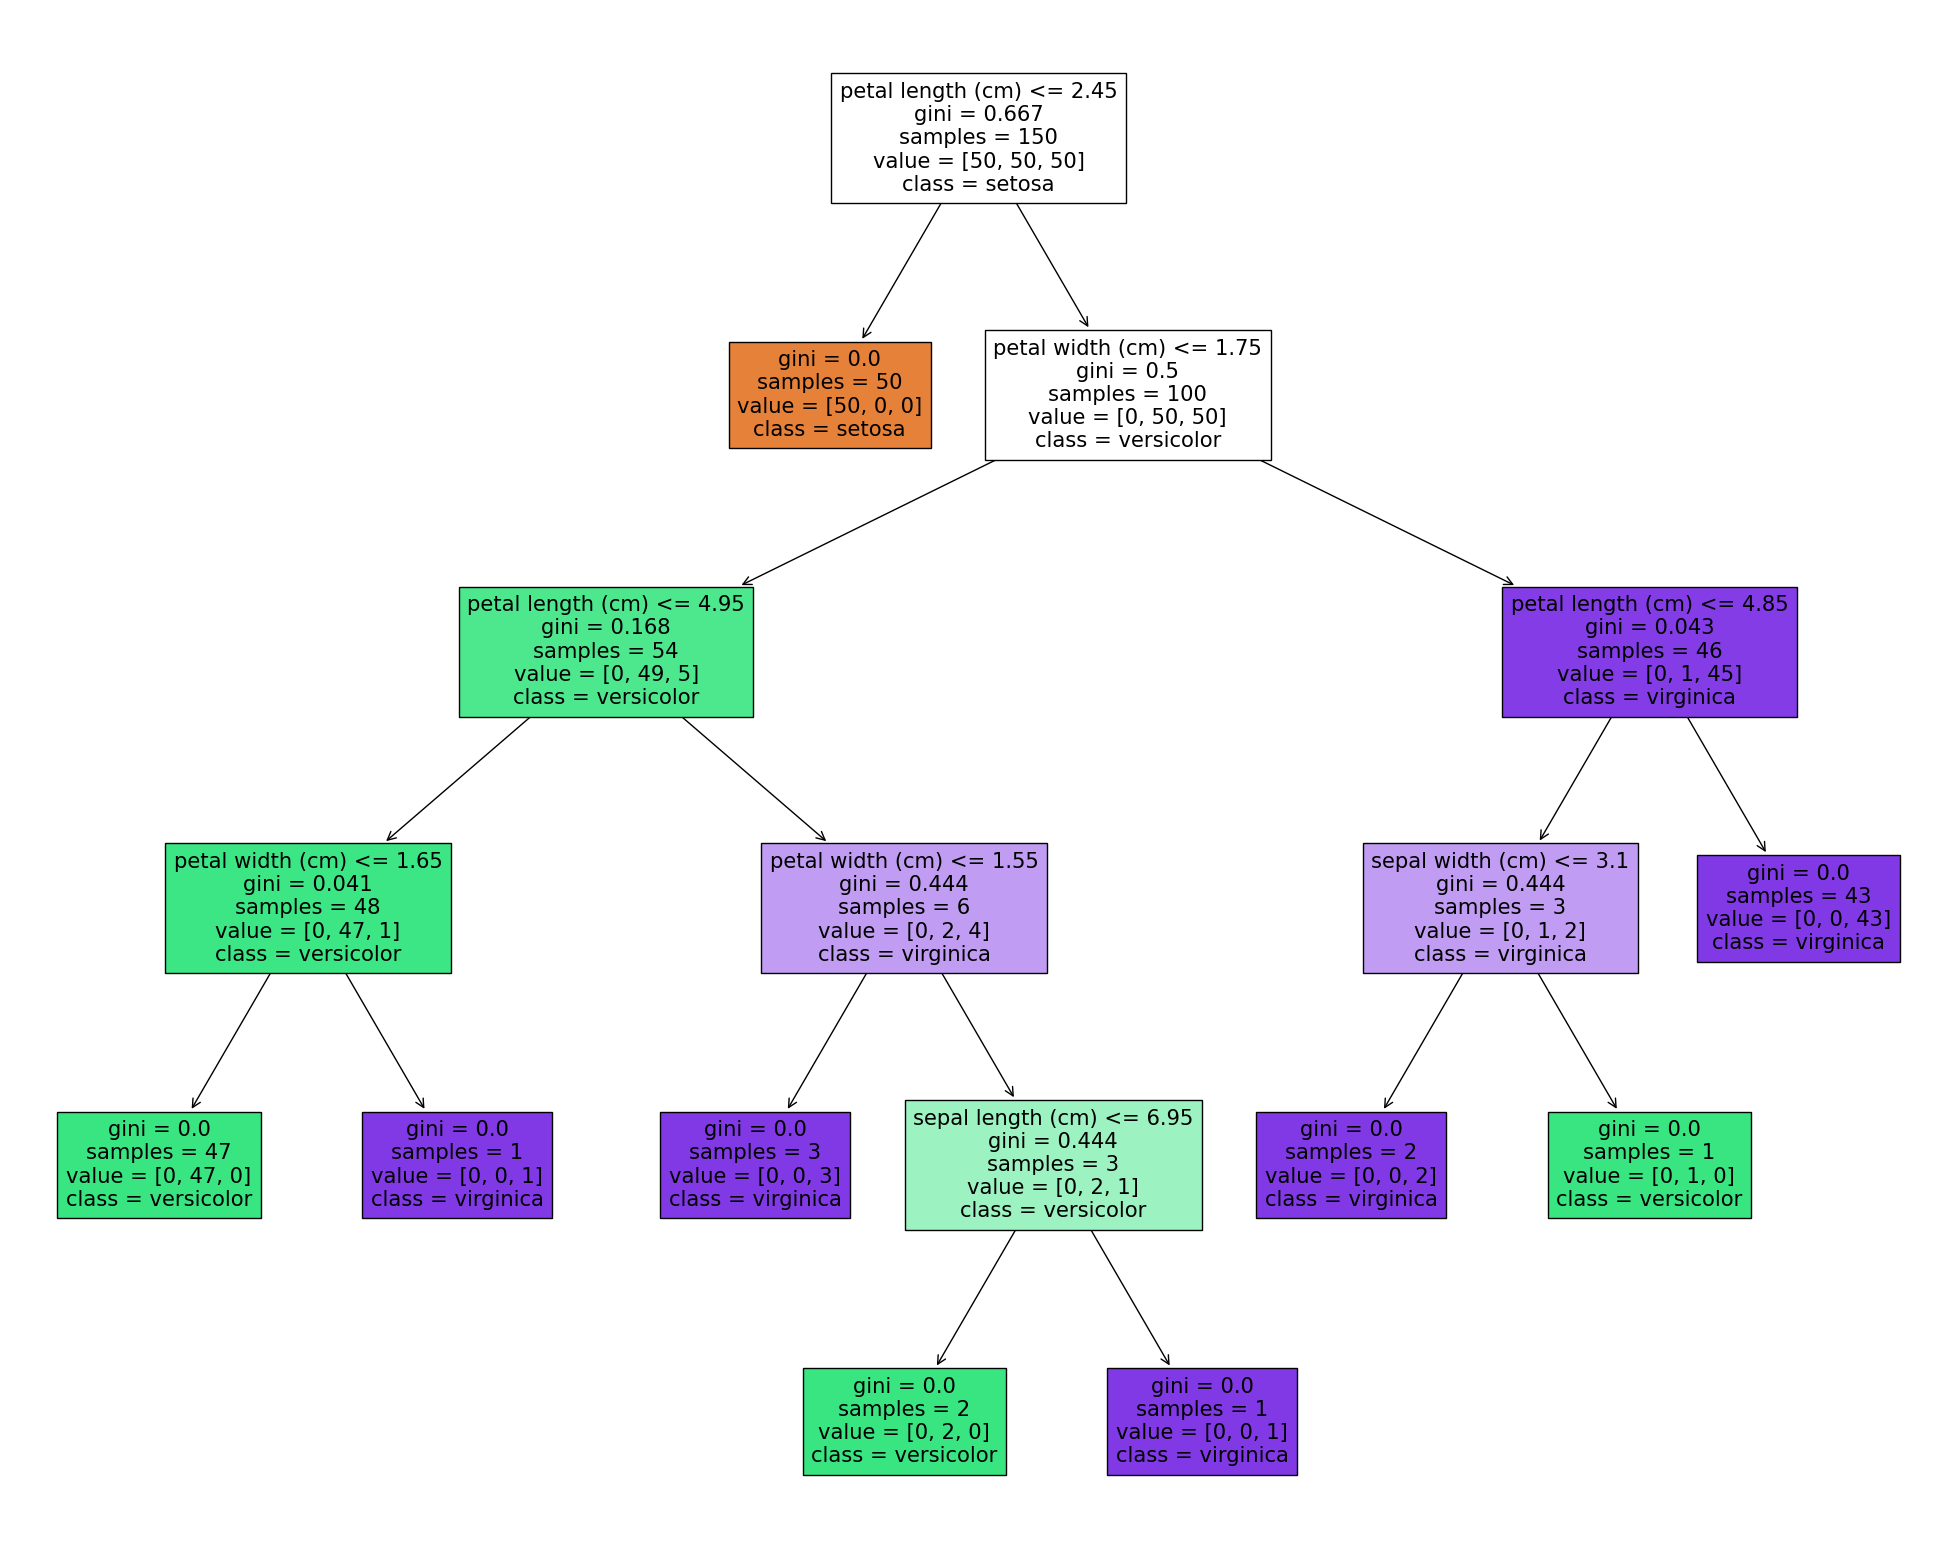

In [10]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(clf,
                   feature_names=iris.feature_names,
                   class_names=iris.target_names,
                   filled=True)

# Import Library & Dataset

In [13]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [15]:
data = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [17]:
data.shape

(891, 12)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data Preprocessing

In [22]:
# first - checking null data
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
# input data for null data in column 'Age'
data.loc[data['Age'].isnull(), 'Age'] = data['Age'].median()

In [28]:
# second - checking duplicate data
data.duplicated().sum()

0

In [30]:
# engineering column 'Sex', Categorical Endocing
data = pd.get_dummies(data, columns=['Sex'], drop_first=True) # Prevent one-hot encoding trap
data.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,True


In [32]:
# last - define X & y
X = data[['Pclass','Age','SibSp','Parch','Fare','Sex_male']]
y = data['Survived']

# Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

In [37]:
# split train and test data from the above dataset
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# agar splitting tidak berubah, diberi random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 45)

In [39]:
# scaling
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [45]:
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male
332,1,38.0,0,1,153.4625,True
281,3,28.0,0,0,7.8542,True
147,3,9.0,2,2,34.3750,False
11,1,58.0,0,0,26.5500,False
405,2,34.0,1,0,21.0000,True


In [47]:
X_train_scaled.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male
0,-1.532879,0.655795,-0.474774,0.744162,2.320077,0.735612
1,0.842333,-0.120045,-0.474774,-0.465526,-0.483321,0.735612
2,0.842333,-1.594141,1.332921,1.953851,0.027284,-1.359412
3,-1.532879,2.207475,-0.474774,-0.465526,-0.123371,-1.359412
4,-0.345273,0.345459,0.429074,-0.465526,-0.230225,0.735612


# Classification Model

## Library